# Multi-Model Topic Assignment: Inter-Model Agreement Analysis

Compares topic assignments across 4 models (Gemini 2.5 FL baseline + GPT-4.1-nano, Ministral 8B, DeepSeek v3.2)
on 11,565 eligible posts. Produces figures for the results section.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
from scipy.stats import entropy as scipy_entropy

# Publication settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

## Load Assignment Data

In [2]:
DATA_DIR = Path('../data')
ASSIGNMENT_DIR = DATA_DIR / 'multi_model_assignment'

# Model display names
MODEL_NAMES = {
    'deepseek_deepseek-chat-v3-0324': 'DeepSeek v3.2',
    'mistralai_ministral-8b': 'Ministral 8B',
    'openai_gpt-4-1-nano': 'GPT-4.1-nano',
}

# Load checkpoints
models = {}
for f in sorted(ASSIGNMENT_DIR.glob('checkpoint_*.json')):
    model_key = f.stem.replace('checkpoint_', '')
    if model_key not in MODEL_NAMES:
        continue
    with open(f) as fh:
        d = json.load(fh)
    models[model_key] = d.get('completed', {})
    valid = sum(1 for v in d['completed'].values() if 'error' not in v)
    errors = len(d['completed']) - valid
    print(f'{MODEL_NAMES[model_key]:<15}: {valid} valid, {errors} errors')

# Load Gemini 2.5 FL baseline
baseline_files = sorted((DATA_DIR / 'topic_assignment').glob(
    'posts_with_topics_google_gemini-2.5-flash-lite_*.parquet'))
baseline_df = pd.read_parquet(baseline_files[-1])
gemini_assignments = dict(zip(baseline_df['post_id'], baseline_df['primary_topic']))
print(f'{"Gemini 2.5 FL":<15}: {len(gemini_assignments)} total ({len(baseline_df)} in baseline file)')

# Load taxonomy
with open(DATA_DIR / 'topic_consolidated' / 'taxonomy_70_complete.json') as f:
    taxonomy = json.load(f)
valid_labels = sorted(set(e['topic'] for e in taxonomy['taxonomy']))
print(f'\nTaxonomy: {len(valid_labels)} topics')

DeepSeek v3.2  : 11571 valid, 14 errors
Ministral 8B   : 11585 valid, 0 errors
GPT-4.1-nano   : 11585 valid, 0 errors
Gemini 2.5 FL  : 32630 total (32630 in baseline file)

Taxonomy: 70 topics


In [3]:
# Get common post IDs across all 4 models
common_ids = set.intersection(
    *[set(k for k, v in completed.items() if 'error' not in v) for completed in models.values()]
) & set(gemini_assignments.keys())
print(f'Common posts across all 4 models: {len(common_ids)}')

# Build assignment DataFrame: one row per post, columns = model primary topics
rows = []
for pid in common_ids:
    row = {'post_id': pid}
    for mk, name in MODEL_NAMES.items():
        t = models[mk][pid].get('primary_topic', '')
        row[name] = t if t and t != 'unknown' else None
    row['Gemini 2.5 FL'] = gemini_assignments.get(pid)
    rows.append(row)

assignment_df = pd.DataFrame(rows)
model_cols = ['DeepSeek v3.2', 'Ministral 8B', 'GPT-4.1-nano', 'Gemini 2.5 FL']
print(f'\nNull rates (including unknown):')
for col in model_cols:
    null_rate = assignment_df[col].isna().mean()
    print(f'  {col:<15}: {null_rate:.1%}')

Common posts across all 4 models: 11571

Null rates (including unknown):
  DeepSeek v3.2  : 0.4%
  Ministral 8B   : 3.0%
  GPT-4.1-nano   : 8.5%
  Gemini 2.5 FL  : 0.0%


## 1. Basic Assignment Statistics

In [4]:
print('ASSIGNMENT BEHAVIOR BY MODEL')
print('=' * 65)

stats_rows = []
for mk, name in list(MODEL_NAMES.items()):
    valid = {k: v for k, v in models[mk].items() if 'error' not in v}
    n_topics_dist = Counter(v.get('n_topics', 1) for v in valid.values())
    primary_counts = Counter(v.get('primary_topic', '') for v in valid.values())
    primary_counts.pop('unknown', None)
    primary_counts.pop('', None)
    
    total = sum(primary_counts.values())
    probs = np.array(list(primary_counts.values())) / total
    h = -np.sum(probs * np.log2(probs))
    top5 = sum(c for _, c in primary_counts.most_common(5)) / total
    n_used = len(primary_counts)
    avg_topics = sum(v.get('n_topics', 1) for v in valid.values()) / len(valid)
    unknowns = sum(1 for v in valid.values() if v.get('primary_topic') == 'unknown')
    
    stats_rows.append({
        'Model': name,
        'Topics used': n_used,
        'Entropy (bits)': h,
        'Top-5 share': top5,
        'Avg topics/post': avg_topics,
        'Unknown rate': unknowns / len(valid),
    })
    print(f'\n{name}:')
    print(f'  Topics assigned per post: 1={n_topics_dist.get(1,0)}, 2={n_topics_dist.get(2,0)}, 3={n_topics_dist.get(3,0)}')
    print(f'  Distinct topics used: {n_used}/70')
    print(f'  Entropy: {h:.2f} bits | Top-5 concentration: {top5:.1%}')
    print(f'  Unknown rate: {unknowns/len(valid):.1%}')

# Add Gemini
gemini_eligible = {pid: gemini_assignments[pid] for pid in common_ids if gemini_assignments.get(pid)}
gemini_counts = Counter(gemini_eligible.values())
total_g = sum(gemini_counts.values())
probs_g = np.array(list(gemini_counts.values())) / total_g
h_g = -np.sum(probs_g * np.log2(probs_g))
top5_g = sum(c for _, c in gemini_counts.most_common(5)) / total_g
stats_rows.append({
    'Model': 'Gemini 2.5 FL',
    'Topics used': len(gemini_counts),
    'Entropy (bits)': h_g,
    'Top-5 share': top5_g,
    'Avg topics/post': np.nan,  # not available from baseline
    'Unknown rate': 0.0,
})
print(f'\nGemini 2.5 FL:')
print(f'  Distinct topics used: {len(gemini_counts)}/70')
print(f'  Entropy: {h_g:.2f} bits | Top-5 concentration: {top5_g:.1%}')

stats_df = pd.DataFrame(stats_rows)
stats_df

ASSIGNMENT BEHAVIOR BY MODEL

DeepSeek v3.2:
  Topics assigned per post: 1=28, 2=620, 3=10923
  Distinct topics used: 70/70
  Entropy: 4.94 bits | Top-5 concentration: 39.0%
  Unknown rate: 0.4%

Ministral 8B:
  Topics assigned per post: 1=60, 2=2729, 3=8796
  Distinct topics used: 67/70
  Entropy: 4.44 bits | Top-5 concentration: 53.8%
  Unknown rate: 3.0%

GPT-4.1-nano:
  Topics assigned per post: 1=385, 2=5487, 3=5713
  Distinct topics used: 58/70
  Entropy: 3.86 bits | Top-5 concentration: 62.7%
  Unknown rate: 8.5%

Gemini 2.5 FL:
  Distinct topics used: 71/70
  Entropy: 4.96 bits | Top-5 concentration: 40.9%


,Model,Topics used,Entropy (bits),Top-5 share,Avg topics/post,Unknown rate
0,DeepSeek v3.2,70,4.936615,0.389761,2.941578,0.003975
1,Ministral 8B,67,4.441049,0.538482,2.754079,0.029866
2,GPT-4.1-nano,58,3.859948,0.627394,2.459905,0.084937
3,Gemini 2.5 FL,71,4.960693,0.409311,NaN,0.000000


## 2. Pairwise Agreement

In [5]:
# Pairwise exact-match agreement on primary topic
pairwise = pd.DataFrame(np.nan, index=model_cols, columns=model_cols)

for i, m1 in enumerate(model_cols):
    for j, m2 in enumerate(model_cols):
        if i == j:
            pairwise.loc[m1, m2] = 1.0
            continue
        mask = assignment_df[m1].notna() & assignment_df[m2].notna()
        if mask.sum() == 0:
            continue
        agree = (assignment_df.loc[mask, m1] == assignment_df.loc[mask, m2]).mean()
        pairwise.loc[m1, m2] = agree

print('Pairwise Agreement Matrix (exact match on primary topic):')
print(pairwise.round(3).to_string())
print(f'\nMean off-diagonal agreement: {pairwise.values[np.triu_indices(4, k=1)].mean():.3f}')

Pairwise Agreement Matrix (exact match on primary topic):
               DeepSeek v3.2  Ministral 8B  GPT-4.1-nano  Gemini 2.5 FL
DeepSeek v3.2          1.000         0.470         0.367          0.619
Ministral 8B           0.470         1.000         0.335          0.458
GPT-4.1-nano           0.367         0.335         1.000          0.336
Gemini 2.5 FL          0.619         0.458         0.336          1.000

Mean off-diagonal agreement: 0.431


## 3. Majority Vote Consensus

In [6]:
# Majority vote analysis
consensus_levels = {'4-model unanimous': 0, '3-model majority': 0,
                    '2-model plurality': 0, 'No majority': 0}
majority_topics = []

for _, row in assignment_df.iterrows():
    topics = [row[c] for c in model_cols if pd.notna(row[c])]
    if len(topics) < 2:
        continue
    counts = Counter(topics)
    top_count = counts.most_common(1)[0][1]
    top_topic = counts.most_common(1)[0][0]
    
    if top_count == 4:
        consensus_levels['4-model unanimous'] += 1
    elif top_count == 3:
        consensus_levels['3-model majority'] += 1
    elif top_count == 2:
        consensus_levels['2-model plurality'] += 1
    else:
        consensus_levels['No majority'] += 1
    majority_topics.append(top_topic)

total = sum(consensus_levels.values())
print('MAJORITY VOTE CONSENSUS')
print('=' * 50)
for level, count in consensus_levels.items():
    print(f'  {level:<25}: {count:>5} ({count/total*100:.1f}%)')
print(f'  {"":<25}: {"---":>5}')
print(f'  {"Total":<25}: {total:>5}')
print(f'\n  Posts with majority (3+): {consensus_levels["4-model unanimous"] + consensus_levels["3-model majority"]} ({(consensus_levels["4-model unanimous"] + consensus_levels["3-model majority"])/total*100:.1f}%)')

MAJORITY VOTE CONSENSUS
  4-model unanimous        :  2056 (17.8%)
  3-model majority         :  3505 (30.3%)
  2-model plurality        :  4744 (41.0%)
  No majority              :  1261 (10.9%)
                           :   ---
  Total                    : 11566

  Posts with majority (3+): 5561 (48.1%)


## 4. Topic-Level Agreement

In [8]:
# For each topic: agreement rate when at least one model assigns it
topic_agreement = []

for topic in valid_labels:
    # Posts where at least one model assigned this topic
    mask = assignment_df[model_cols].eq(topic).any(axis=1)
    posts_with_topic = assignment_df[mask]
    
    if len(posts_with_topic) < 20:
        continue
    
    agree_2plus = 0
    for _, row in posts_with_topic.iterrows():
        n_agree = sum(1 for c in model_cols if row[c] == topic)
        if n_agree >= 2:
            agree_2plus += 1
    
    topic_agreement.append({
        'topic': topic,
        'n_posts': len(posts_with_topic),
        'agree_2plus': agree_2plus,
        'agreement_rate': agree_2plus / len(posts_with_topic)
    })

topic_agree_df = pd.DataFrame(topic_agreement).sort_values('agreement_rate', ascending=False)

print('TOP 10 HIGH-AGREEMENT TOPICS (concrete/unambiguous):')
for _, row in topic_agree_df.head(10).iterrows():
    print(f"  {row['topic']:<42} {row['agreement_rate']:.0%} ({row['agree_2plus']}/{row['n_posts']})")

print(f'\nTOP 10 LOW-AGREEMENT TOPICS (abstract/ambiguous):')
for _, row in topic_agree_df.tail(10).iterrows():
    print(f"  {row['topic']:<42} {row['agreement_rate']:.0%} ({row['agree_2plus']}/{row['n_posts']})")

TOP 10 HIGH-AGREEMENT TOPICS (concrete/unambiguous):
  financial_disagreements                    77% (344/448)
  intimacy_sexual_compatibility              75% (733/974)
  hygiene_cleanliness_issues                 74% (59/80)
  polyamory_open_relationships               68% (89/131)
  addiction_substance_abuse                  67% (208/311)
  grief_loss_bereavement                     66% (46/70)
  infidelity_cheating                        63% (1343/2117)
  cultural_religious_differences             62% (136/218)
  controlling_abusive_behavior               62% (786/1261)
  pet_ownership_conflicts                    61% (27/44)

TOP 10 LOW-AGREEMENT TOPICS (abstract/ambiguous):
  inappropriate_family_attraction            25% (8/32)
  relationship_uncertainty_doubt             24% (289/1227)
  post_breakup_dynamics                      23% (29/128)
  emotional_dependency_codependency          21% (255/1219)
  romantic_feelings_disclosure               20% (13/65)
  self_sabotage_fea

## 5. Model-Specific Assignment Biases

In [9]:
# Compute per-model topic distributions and corpus average
model_dists = {}
for col in model_cols:
    counts = assignment_df[col].value_counts(dropna=True)
    total = counts.sum()
    model_dists[col] = (counts / total).to_dict()

# Corpus average
all_topics_seen = set()
for d in model_dists.values():
    all_topics_seen.update(d.keys())

corpus_avg = {}
for t in all_topics_seen:
    vals = [d.get(t, 0) for d in model_dists.values()]
    corpus_avg[t] = np.mean(vals)

# Per-model over/under-assignments
print('MODEL-SPECIFIC ASSIGNMENT BIASES')
print('=' * 70)
print('(Ratio = model share / corpus average share; common topics only)')

bias_rows = []
for model in model_cols:
    for t in all_topics_seen:
        mp = model_dists[model].get(t, 0)
        ap = corpus_avg[t]
        if ap > 0.005:  # only non-rare topics
            ratio = mp / ap if ap > 0 else 0
            bias_rows.append({
                'model': model, 'topic': t,
                'model_share': mp, 'corpus_avg': ap, 'ratio': ratio
            })

bias_df = pd.DataFrame(bias_rows)

for model in model_cols:
    print(f'\n  {model}:')
    mb = bias_df[bias_df['model'] == model].sort_values('ratio', ascending=False)
    print(f'    OVER-assigns:')
    for _, row in mb.head(5).iterrows():
        print(f'      {row["topic"]:<40} {row["model_share"]*100:.1f}% vs avg {row["corpus_avg"]*100:.1f}% (x{row["ratio"]:.1f})')
    print(f'    UNDER-assigns:')
    under = mb[mb['ratio'] < 0.5].sort_values('ratio')
    for _, row in under.head(3).iterrows():
        print(f'      {row["topic"]:<40} {row["model_share"]*100:.1f}% vs avg {row["corpus_avg"]*100:.1f}% (x{row["ratio"]:.1f})')

MODEL-SPECIFIC ASSIGNMENT BIASES
(Ratio = model share / corpus average share; common topics only)

  DeepSeek v3.2:
    OVER-assigns:
      attraction_compatibility_mismatch        2.6% vs avg 1.1% (x2.4)
      past_trauma_relationship_impact          1.7% vs avg 0.8% (x2.1)
      pornography_ai_relationship_concerns     0.9% vs avg 0.5% (x1.7)
      polyamory_open_relationships             1.0% vs avg 0.6% (x1.6)
      lifestyle_incompatibility                1.5% vs avg 0.9% (x1.6)
    UNDER-assigns:
      relationship_exclusivity_commitment      0.1% vs avg 2.6% (x0.1)
      relationship_uncertainty_doubt           1.0% vs avg 3.6% (x0.3)
      emotional_dependency_codependency        1.6% vs avg 3.5% (x0.4)

  Ministral 8B:
    OVER-assigns:
      relationship_exclusivity_commitment      9.0% vs avg 2.6% (x3.5)
      infidelity_cheating                      16.9% vs avg 10.0% (x1.7)
      relationship_effort_imbalance            12.1% vs avg 7.7% (x1.6)
      addiction_substance_ab

## Figure: Pairwise Agreement Heatmap + Majority Vote Distribution

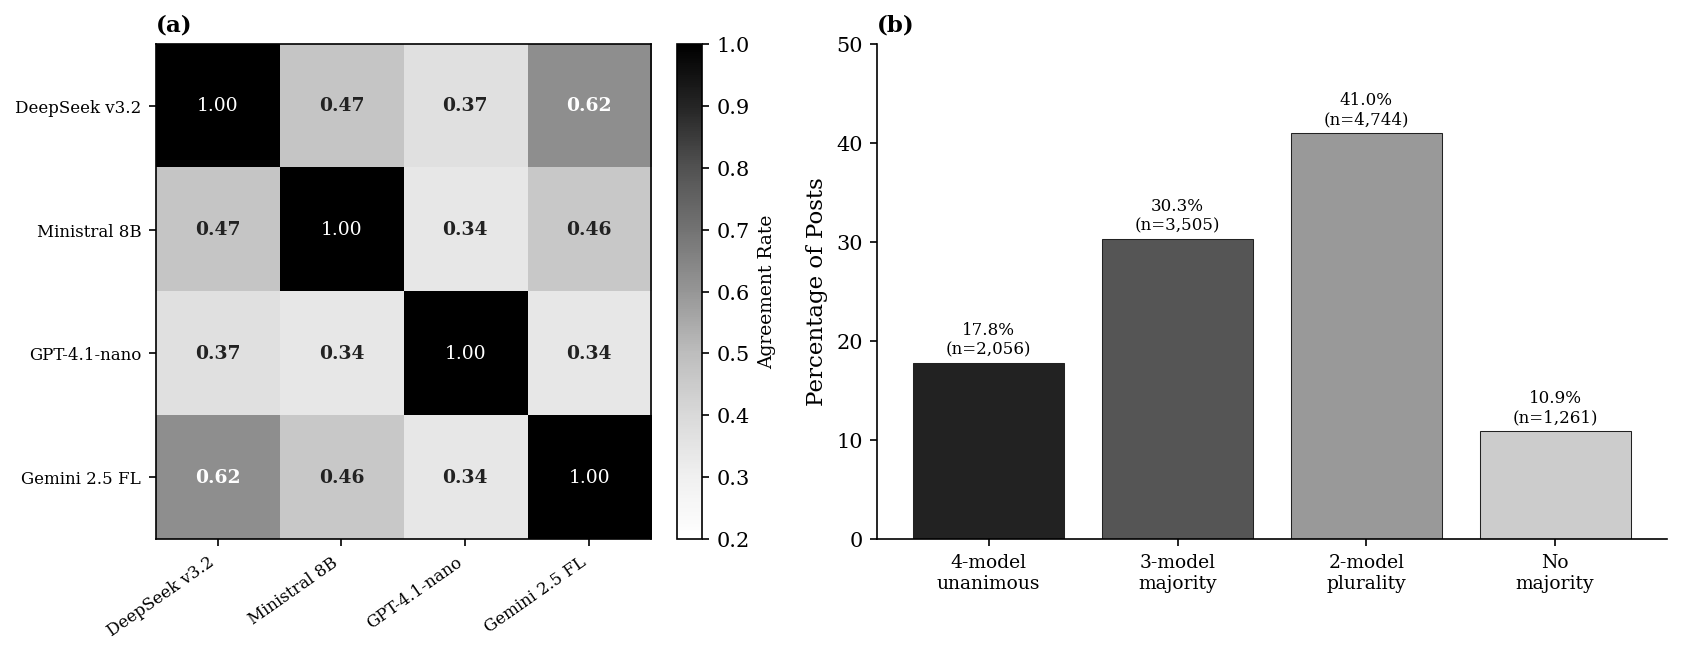

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150,
                                gridspec_kw={'width_ratios': [1, 1.2]})

# --- Panel (a): Pairwise agreement heatmap ---
im = ax1.imshow(pairwise.values.astype(float), cmap='Greys', vmin=0.2, vmax=1.0, aspect='equal')
ax1.set_xticks(range(4))
ax1.set_xticklabels(model_cols, rotation=35, ha='right', fontsize=8)
ax1.set_yticks(range(4))
ax1.set_yticklabels(model_cols, fontsize=8)

for i in range(4):
    for j in range(4):
        val = pairwise.iloc[i, j]
        color = 'white' if val > 0.55 else '#222222'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold' if i != j else 'normal')

cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('Agreement Rate', fontsize=9)
ax1.set_title('(a)', fontsize=11, fontweight='bold', loc='left')

# --- Panel (b): Majority vote distribution ---
levels = ['4-model\nunanimous', '3-model\nmajority', '2-model\nplurality', 'No\nmajority']
counts = [consensus_levels['4-model unanimous'], consensus_levels['3-model majority'],
          consensus_levels['2-model plurality'], consensus_levels['No majority']]
pcts = [c/total*100 for c in counts]

colors = ['#222222', '#555555', '#999999', '#cccccc']
bars = ax2.bar(range(4), pcts, color=colors, edgecolor='#222222', linewidth=0.5)

for bar, pct, count in zip(bars, pcts, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%\n(n={count:,})', ha='center', va='bottom', fontsize=8)

ax2.set_xticks(range(4))
ax2.set_xticklabels(levels, fontsize=9)
ax2.set_ylabel('Percentage of Posts')
ax2.set_ylim(0, 50)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('(b)', fontsize=11, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

## Figure: Assignment Bias Comparison

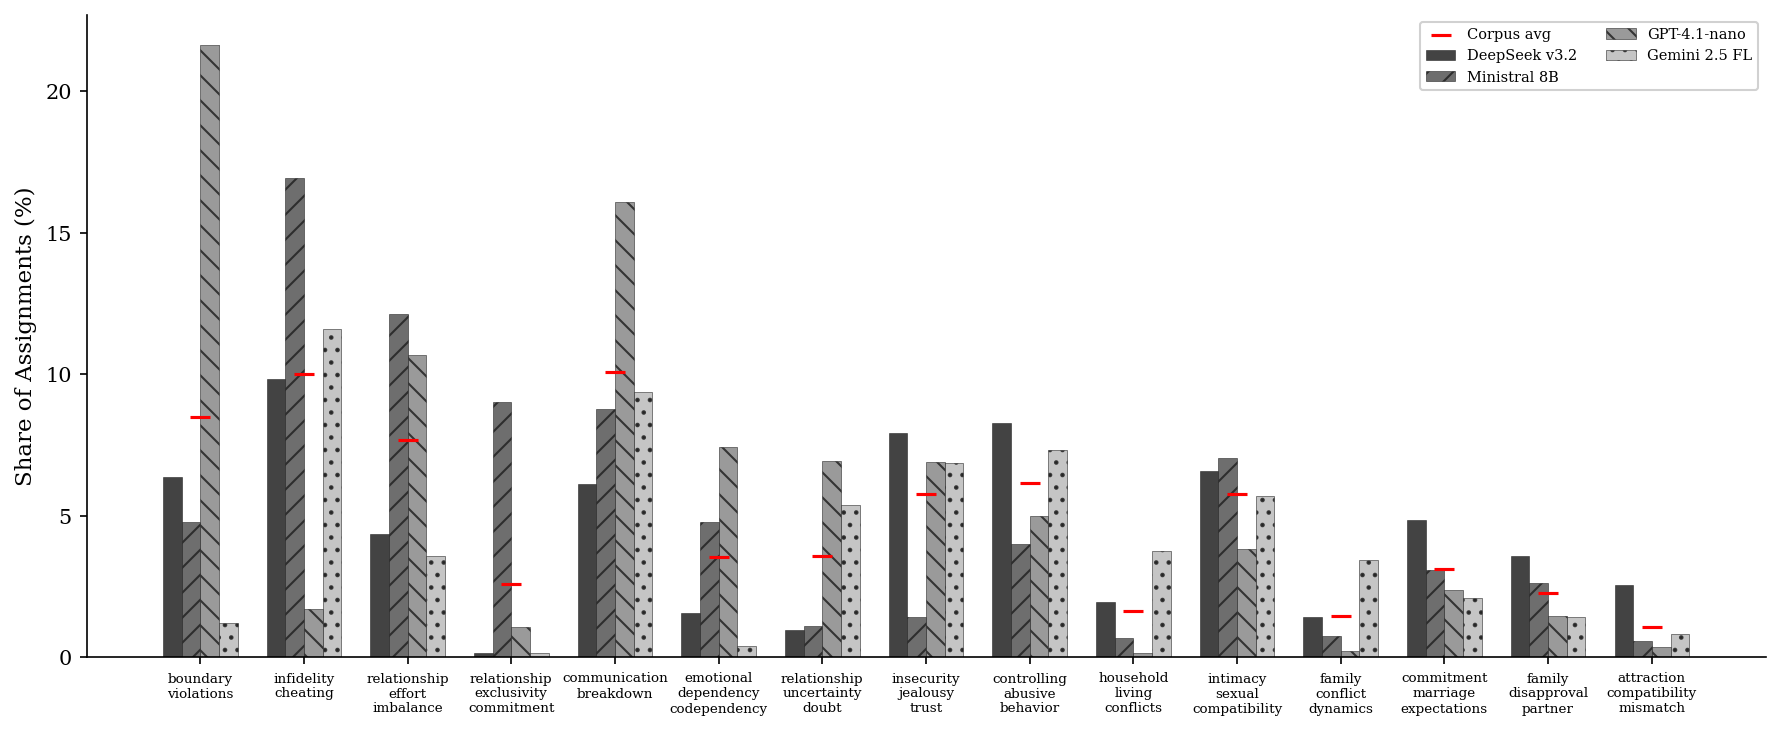

In [11]:
# Select topics with highest variance across models (where they disagree most)
topic_var = {}
for t in all_topics_seen:
    shares = [model_dists[m].get(t, 0) for m in model_cols]
    if max(shares) > 0.01:  # only non-trivial topics
        topic_var[t] = np.var(shares)

top_var_topics = sorted(topic_var, key=topic_var.get, reverse=True)[:15]

# Create grouped bar chart
fig, ax = plt.subplots(1, 1, figsize=(12, 5), dpi=150)

n_topics = len(top_var_topics)
n_models = len(model_cols)
bar_width = 0.18
x = np.arange(n_topics)

GREYS = ['#222222', '#555555', '#888888', '#bbbbbb']
HATCHES = ['', '//', '\\\\', '..']

for i, model in enumerate(model_cols):
    offset = (i - n_models/2 + 0.5) * bar_width
    vals = [model_dists[model].get(t, 0) * 100 for t in top_var_topics]
    ax.bar(x + offset, vals, bar_width, color=GREYS[i], edgecolor='#222222',
           linewidth=0.3, label=model, hatch=HATCHES[i], alpha=0.85)

# Corpus average line markers
avg_vals = [corpus_avg.get(t, 0) * 100 for t in top_var_topics]
ax.scatter(x, avg_vals, marker='_', color='red', s=100, zorder=5, linewidths=1.5, label='Corpus avg')

ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', '\n') for t in top_var_topics], fontsize=6.5, ha='center')
ax.set_ylabel('Share of Assignments (%)')
ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, None)

plt.tight_layout()
plt.show()

## Figure: Topic-Level Agreement (sorted)

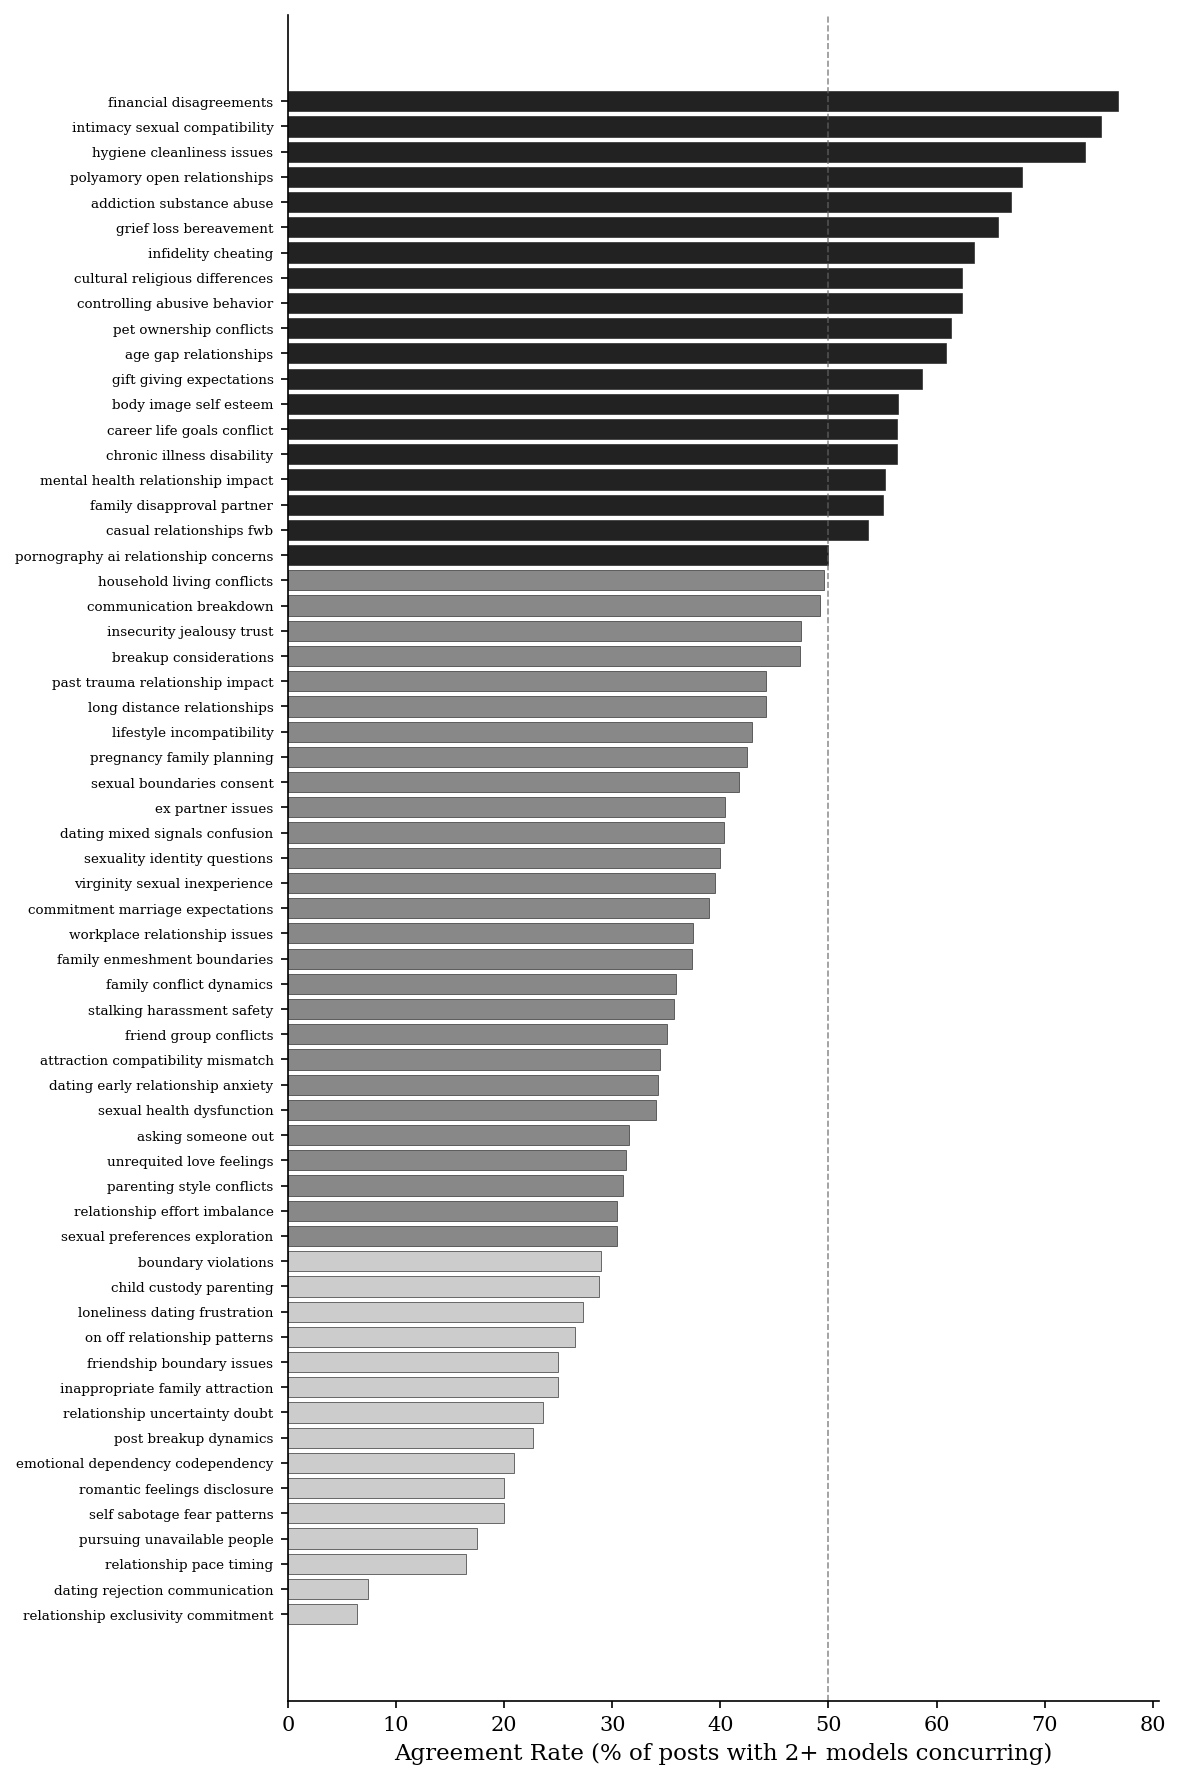

In [12]:
# Horizontal bar chart of topic agreement rates
plot_df = topic_agree_df.sort_values('agreement_rate', ascending=True)

fig, ax = plt.subplots(1, 1, figsize=(8, 12), dpi=150)

colors = ['#222222' if r >= 0.5 else '#888888' if r >= 0.3 else '#cccccc'
          for r in plot_df['agreement_rate']]

y_pos = range(len(plot_df))
ax.barh(y_pos, plot_df['agreement_rate'] * 100, color=colors,
        edgecolor='#222222', linewidth=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels([t.replace('_', ' ') for t in plot_df['topic']], fontsize=6.5)
ax.set_xlabel('Agreement Rate (% of posts with 2+ models concurring)')
ax.axvline(x=50, color='#666666', linestyle='--', linewidth=0.8, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## GPT-nano 'Unknown' Analysis

In [13]:
# What topics do other models assign to posts GPT-nano calls 'unknown'?
gpt_mk = 'openai_gpt-4-1-nano'
gpt_unknowns = [pid for pid, v in models[gpt_mk].items()
                if v.get('primary_topic') == 'unknown' and 'error' not in v]

other_for_unknowns = Counter()
for pid in gpt_unknowns:
    for mk in ['deepseek_deepseek-chat-v3-0324', 'mistralai_ministral-8b']:
        t = models[mk].get(pid, {}).get('primary_topic', '')
        if t and t != 'unknown':
            other_for_unknowns[t] += 1
    gt = gemini_assignments.get(pid, '')
    if gt:
        other_for_unknowns[gt] += 1

print(f'GPT-4.1-nano assigned "unknown" to {len(gpt_unknowns)} posts ({len(gpt_unknowns)/11571*100:.1f}%).')
print(f'\nWhat other models assigned to those posts (combined votes):')
for topic, count in other_for_unknowns.most_common(10):
    pct = count / sum(other_for_unknowns.values()) * 100
    print(f'  {topic:<45} {count:>5} ({pct:.1f}%)')

GPT-4.1-nano assigned "unknown" to 984 posts (8.5%).

What other models assigned to those posts (combined votes):
  infidelity_cheating                            1532 (54.4%)
  insecurity_jealousy_trust                       529 (18.8%)
  communication_breakdown                          93 (3.3%)
  addiction_substance_abuse                        77 (2.7%)
  boundary_violations                              63 (2.2%)
  relationship_uncertainty_doubt                   52 (1.8%)
  controlling_abusive_behavior                     49 (1.7%)
  ex_partner_issues                                40 (1.4%)
  pornography_ai_relationship_concerns             37 (1.3%)
  relationship_exclusivity_commitment              30 (1.1%)


## Summary Statistics for Paper

In [14]:
print('KEY STATISTICS FOR RESULTS SECTION')
print('=' * 60)
print(f'\nN eligible posts: {len(common_ids):,}')
print(f'N models: 4 (1 baseline + 3 additional)')

print(f'\nEntropy range: {stats_df["Entropy (bits)"].min():.2f} - {stats_df["Entropy (bits)"].max():.2f} bits')
print(f'Top-5 concentration range: {stats_df["Top-5 share"].min():.1%} - {stats_df["Top-5 share"].max():.1%}')

off_diag = pairwise.values[np.triu_indices(4, k=1)]
print(f'\nPairwise agreement:')
print(f'  Range: {off_diag.min():.1%} - {off_diag.max():.1%}')
print(f'  Mean: {off_diag.mean():.1%}')
print(f'  Best pair: DeepSeek <-> Gemini FL ({pairwise.loc["DeepSeek v3.2", "Gemini 2.5 FL"]:.1%})')
print(f'  Worst pair: Ministral <-> GPT-nano ({pairwise.loc["Ministral 8B", "GPT-4.1-nano"]:.1%})')

print(f'\nConsensus:')
print(f'  4-model unanimous: {consensus_levels["4-model unanimous"]/total*100:.1f}%')
print(f'  3+ majority: {(consensus_levels["4-model unanimous"]+consensus_levels["3-model majority"])/total*100:.1f}%')
print(f'  No majority: {consensus_levels["No majority"]/total*100:.1f}%')

print(f'\nTopic agreement range: {topic_agree_df["agreement_rate"].min():.0%} - {topic_agree_df["agreement_rate"].max():.0%}')
print(f'  Median: {topic_agree_df["agreement_rate"].median():.0%}')

KEY STATISTICS FOR RESULTS SECTION

N eligible posts: 11,571
N models: 4 (1 baseline + 3 additional)

Entropy range: 3.86 - 4.96 bits
Top-5 concentration range: 39.0% - 62.7%

Pairwise agreement:
  Range: 33.5% - 61.9%
  Mean: 43.1%
  Best pair: DeepSeek <-> Gemini FL (61.9%)
  Worst pair: Ministral <-> GPT-nano (33.5%)

Consensus:
  4-model unanimous: 17.8%
  3+ majority: 48.1%
  No majority: 10.9%

Topic agreement range: 6% - 77%
  Median: 40%


## Save Figures

In [15]:
fig_dir = Path('../figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# --- (a+b) Agreement + Consensus ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), dpi=150,
                                gridspec_kw={'width_ratios': [1, 1.2]})

im = ax1.imshow(pairwise.values.astype(float), cmap='Greys', vmin=0.2, vmax=1.0, aspect='equal')
ax1.set_xticks(range(4))
ax1.set_xticklabels(model_cols, rotation=35, ha='right', fontsize=8)
ax1.set_yticks(range(4))
ax1.set_yticklabels(model_cols, fontsize=8)
for i in range(4):
    for j in range(4):
        val = pairwise.iloc[i, j]
        color = 'white' if val > 0.55 else '#222222'
        ax1.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold' if i != j else 'normal')
cbar = plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('Agreement Rate', fontsize=9)
ax1.set_title('(a)', fontsize=11, fontweight='bold', loc='left')

levels = ['4-model\nunanimous', '3-model\nmajority', '2-model\nplurality', 'No\nmajority']
counts_list = [consensus_levels['4-model unanimous'], consensus_levels['3-model majority'],
               consensus_levels['2-model plurality'], consensus_levels['No majority']]
pcts_list = [c/total*100 for c in counts_list]
colors_bar = ['#222222', '#555555', '#999999', '#cccccc']
bars = ax2.bar(range(4), pcts_list, color=colors_bar, edgecolor='#222222', linewidth=0.5)
for bar, pct, count in zip(bars, pcts_list, counts_list):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%\n(n={count:,})', ha='center', va='bottom', fontsize=8)
ax2.set_xticks(range(4))
ax2.set_xticklabels(levels, fontsize=9)
ax2.set_ylabel('Percentage of Posts')
ax2.set_ylim(0, 50)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_title('(b)', fontsize=11, fontweight='bold', loc='left')
plt.tight_layout()
fig.savefig(fig_dir / 'fig_assignment_agreement.pdf', bbox_inches='tight', dpi=300)
fig.savefig(fig_dir / 'fig_assignment_agreement.png', bbox_inches='tight', dpi=300)
print('Saved: fig_assignment_agreement')
plt.close()

# --- Assignment bias bars ---
fig, ax = plt.subplots(1, 1, figsize=(12, 5), dpi=150)
for i, model in enumerate(model_cols):
    offset = (i - n_models/2 + 0.5) * bar_width
    vals = [model_dists[model].get(t, 0) * 100 for t in top_var_topics]
    ax.bar(x + offset, vals, bar_width, color=GREYS[i], edgecolor='#222222',
           linewidth=0.3, label=model, hatch=HATCHES[i], alpha=0.85)
avg_vals = [corpus_avg.get(t, 0) * 100 for t in top_var_topics]
ax.scatter(x, avg_vals, marker='_', color='red', s=100, zorder=5, linewidths=1.5, label='Corpus avg')
ax.set_xticks(x)
ax.set_xticklabels([t.replace('_', '\n') for t in top_var_topics], fontsize=6.5, ha='center')
ax.set_ylabel('Share of Assignments (%)')
ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, None)
plt.tight_layout()
fig.savefig(fig_dir / 'fig_assignment_bias.pdf', bbox_inches='tight', dpi=300)
fig.savefig(fig_dir / 'fig_assignment_bias.png', bbox_inches='tight', dpi=300)
print('Saved: fig_assignment_bias')
plt.close()

print('\nAll figures saved.')

Saved: fig_assignment_agreement
Saved: fig_assignment_bias

All figures saved.
